## Advanced Unsupervised Machine Learning & Model Interpretation – Implementation

#### Dataset Selection

##### 1. Wholesale Customers Dataset (Clustering)

##### 2. Mobile Price Dataset (High-Dimensional Data)

#### Import Libraries

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    MeanShift,
    estimate_bandwidth
)

from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings("ignore")


#### Loading the Clustering Dataset (Wholesale Customers Dataset)

The Wholesale Customers dataset is loaded to perform clustering analysis using different unsupervised learning algorithms.

In [3]:
wholesale_df = pd.read_csv("Datasets/wholesale_customers_data.csv")
wholesale_df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### Data Inspection

In [4]:
print("Dataset Shape:", wholesale_df.shape)

print("\nDataset Information:")
wholesale_df.info()

print("\nMissing Values:")
print(wholesale_df.isnull().sum())

print("\nDuplicate Rows:", wholesale_df.duplicated().sum())

print("\nStatistical Summary:")
display(wholesale_df.describe())


Dataset Shape: (440, 8)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB

Missing Values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Duplicate Rows: 0

Statistical Summary:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


**Observation:**
- The dataset contains **440 records** and **8 numerical features**.
- No missing values or duplicate records were found.
- All features are stored as integer values.
- The feature ranges vary significantly, indicating that feature scaling is required before clustering.
- Some features have very large maximum values compared to their quartiles, suggesting the presence of outliers.

#### Data Preprocessing

- ##### Handling Outliers

In [5]:
wholesale_clean = wholesale_df.copy()

# Detect and remove outliers using the IQR method
Q1 = wholesale_clean.quantile(0.25)
Q3 = wholesale_clean.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ~((wholesale_clean < (Q1 - 1.5 * IQR)) |
                 (wholesale_clean > (Q3 + 1.5 * IQR))).any(axis=1)
wholesale_clean = wholesale_clean[outlier_mask]

print("Original Shape :", wholesale_df.shape)
print("After Removing Outliers :", wholesale_clean.shape)


Original Shape : (440, 8)
After Removing Outliers : (332, 8)


- ##### Feature Scaling

In [6]:
# Separate features
X = wholesale_clean.copy()

# Apply different scaling techniques
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

X_standard = standard_scaler.fit_transform(X)
X_minmax = minmax_scaler.fit_transform(X)
X_robust = robust_scaler.fit_transform(X)
print("StandardScaler Shape:", X_standard.shape)
print("MinMaxScaler Shape:", X_minmax.shape)
print("RobustScaler Shape:", X_robust.shape)


StandardScaler Shape: (332, 8)
MinMaxScaler Shape: (332, 8)
RobustScaler Shape: (332, 8)


**Observation:**
- Feature scaling changed only the feature values, not the number of records or features.
- The scaled datasets are now ready for clustering analysis.

## Clustering Algorithms

This section applies and compares different clustering algorithms on the preprocessed Wholesale Customers dataset.

### 1. K-Means Clustering

- #### Elbow Method

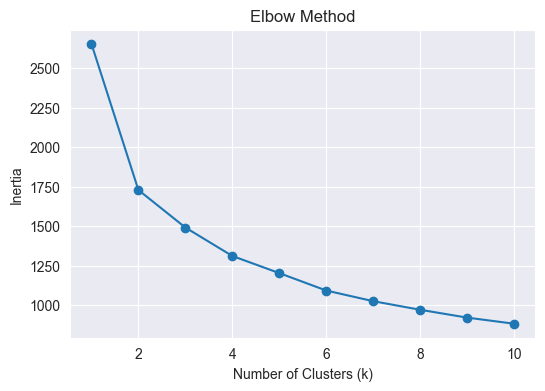

In [7]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_standard)
    inertia.append(kmeans.inertia_)
# Plot the Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


**Observation:**
**3** is the optimal number of clusters. After **k = 3**, the reduction in inertia becomes gradual suggesting that adding more clusters provides only marginal improvement.

- ####  Hyperparameter Tuning

In [8]:
# Hyperparameter tuning using Silhouette Score
results = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_standard)

    results.append({
        "k": k,
        "Silhouette Score": silhouette_score(X_standard, labels)
    })
kmeans_results = pd.DataFrame(results)
display(kmeans_results)

,k,Silhouette Score
0,2,0.356105
1,3,0.260767
2,4,0.259910
3,5,0.223853
4,6,0.233643


- The highest **Silhouette Score (0.3561)** was obtained for **k = 2**.
- Therefore, **k = 2** was selected as the optimal number of clusters.

- #### Applying K-Means Clustering

In [9]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_standard)
# Display cluster distribution
print("Cluster Distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())


Cluster Distribution:
0     99
1    233
Name: count, dtype: int64


- The K-Means model formed **2 clusters**.
- The clusters contain **99** and **233** samples, respectively.

- #### Evaluating K-Means Clustering

In [10]:
silhouette = silhouette_score(X_standard, kmeans_labels)
davies = davies_bouldin_score(X_standard, kmeans_labels)
calinski = calinski_harabasz_score(X_standard, kmeans_labels)
inertia = kmeans.inertia_

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")
print(f"Inertia: {inertia:.4f}")


Silhouette Score: 0.3561
Davies-Bouldin Index: 1.2004
Calinski-Harabasz Index: 176.6546
Inertia: 1729.9359


- #### Cluster Visualization using PCA

Principal Component Analysis (PCA) is used to reduce the dataset to two dimensions for visualizing the clusters formed by the K-Means algorithm.

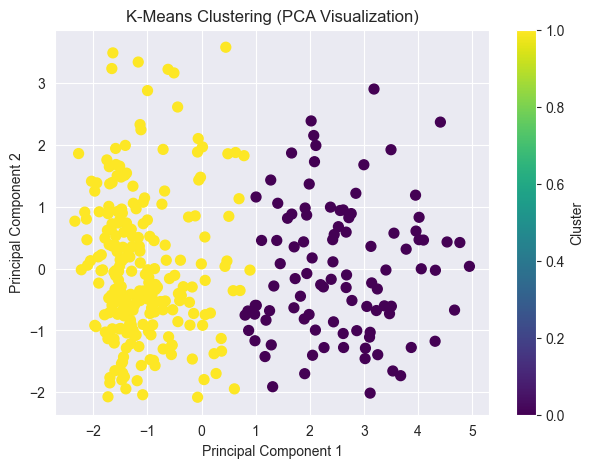

In [11]:
# Reduce the data to two dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standard)
# Visualize the clusters
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50)

plt.title("K-Means Clustering (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

- PCA visualization shows **two reasonably separated clusters**.
- A slight overlap exists between the clusters.
- The visualization supports the evaluation metrics obtained earlier.

### 2. Hierarchical Clustering

- ####  Dendrogram

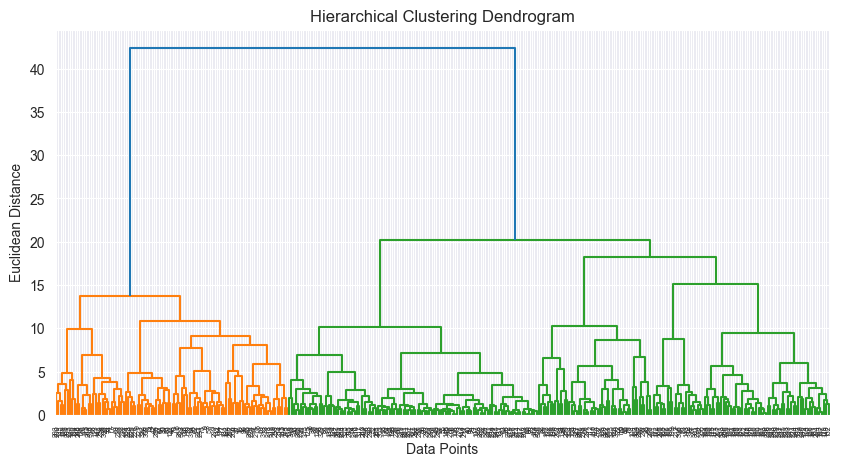

In [12]:
# Create the linkage matrix
linked = linkage(X_standard, method='ward')
# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

**Observation**

- The dendrogram suggests **2 major clusters**.
- This supports the optimal number of clusters obtained from K-Means.

- ####  Hyperparameter Tuning

In [13]:
# Hyperparameter tuning for Hierarchical Clustering
linkage_methods = ["ward", "complete", "average", "single"]
results = []

for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = model.fit_predict(X_standard)

    results.append({
        "Linkage": method,
        "Silhouette Score": silhouette_score(X_standard, labels)
    })
hierarchical_results = pd.DataFrame(results)
display(hierarchical_results)


,Linkage,Silhouette Score
0,ward,0.348924
1,complete,0.261539
2,average,0.352080
3,single,0.246030


**Observation**

- **Average linkage** achieved the highest **Silhouette Score (0.3521)**.
- Therefore, **Average linkage** was selected for the final Hierarchical Clustering model.

- #### Applying Hierarchical Clustering

In [14]:
# Apply Hierarchical Clustering
hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage="average"
)
hierarchical_labels = hierarchical.fit_predict(X_standard)

# Display cluster distribution
print("Cluster Distribution:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

Cluster Distribution:
0    236
1     96
Name: count, dtype: int64


- #### Evaluating Hierarchical Clustering


In [15]:
silhouette = silhouette_score(X_standard, hierarchical_labels)
davies = davies_bouldin_score(X_standard, hierarchical_labels)
calinski = calinski_harabasz_score(X_standard, hierarchical_labels)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")

Silhouette Score: 0.3521
Davies-Bouldin Index: 1.2075
Calinski-Harabasz Index: 169.8709


- #### Cluster Visualization using PCA

  Principal Component Analysis (PCA) is used to reduce the dataset to two dimensions for visualizing the clusters formed by the Hierarchical Clustering algorithm.

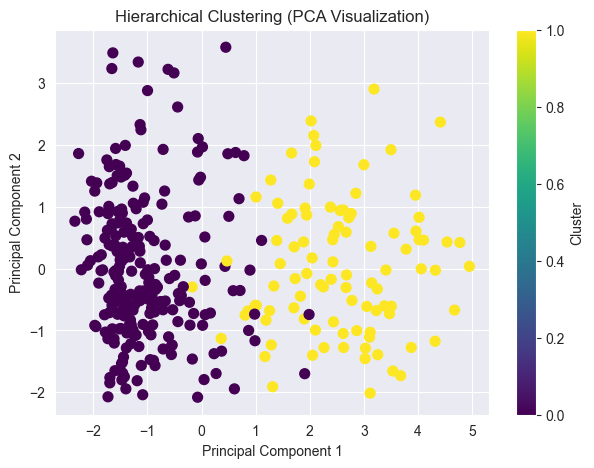

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='viridis', s=50)

plt.title("Hierarchical Clustering (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()


   - The PCA plot shows two reasonably separated clusters.
- The cluster distribution is similar to K-Means.

### 3. DBSCAN

- #### Hyperparameter Tuning

  DBSCAN is tuned by testing different values of **eps** and **min_samples**. The best combination is selected based on the Silhouette Score.

In [17]:
eps_values = [0.3, 0.5, 0.7, 0.9]
min_samples_values = [3, 5, 7]

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_standard)

        # Ignore cases with only one cluster or all noise
        if len(set(labels)) > 1 and len(set(labels)) != len(labels):
            score = silhouette_score(X_standard, labels)

            results.append({
                "eps": eps,
                "min_samples": min_samples,
                "Silhouette Score": score
            })
dbscan_results = pd.DataFrame(results)
dbscan_results = dbscan_results.sort_values(
    by="Silhouette Score",
    ascending=False
)
display(dbscan_results)


,eps,min_samples,Silhouette Score
8,0.9,5,0.080306
9,0.9,7,0.046417
5,0.7,5,0.028202
6,0.7,7,0.004570
2,0.5,5,-0.093106
3,0.5,7,-0.163038
7,0.9,3,-0.167796
4,0.7,3,-0.177603
0,0.3,3,-0.190715
1,0.5,3,-0.222464


**Observation**

- The highest **Silhouette Score (0.0803)** was obtained with **eps = 0.9** and **min_samples = 5**.
- These parameters were selected for the final DBSCAN model.

- #### Applying DBSCAN

In [18]:
# Apply DBSCAN with the best hyperparameters
dbscan = DBSCAN(eps=0.9, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_standard)

# Display cluster distribution
print("Cluster Distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())


Cluster Distribution:
-1    214
 0    101
 1     17
Name: count, dtype: int64


- #### Evaluating DBSCAN

In [19]:
mask = dbscan_labels != -1

silhouette = silhouette_score(X_standard[mask], dbscan_labels[mask])
davies = davies_bouldin_score(X_standard[mask], dbscan_labels[mask])
calinski = calinski_harabasz_score(X_standard[mask], dbscan_labels[mask])
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")


Silhouette Score: 0.4739
Davies-Bouldin Index: 0.8011
Calinski-Harabasz Index: 67.4590


- #### Cluster Visualization using PCA
  Principal Component Analysis (PCA) is used to visualize the clusters and noise points identified by DBSCAN.

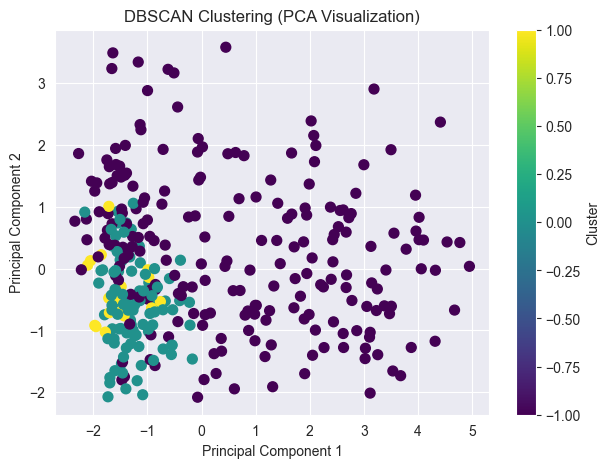

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap="viridis", s=50)

plt.title("DBSCAN Clustering (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()


- DBSCAN identified a large number of noise points (-1).
- Only two small clusters were formed, while most samples were treated as noise.

### 4. Gaussian Mixture Models (GMM)

- #### Hyperparameter Tuning
  The Gaussian Mixture Model is tuned by testing different numbers of components. The best number of components is selected based on the Silhouette Score.

In [21]:
results = []
for n in range(2, 7):
    gmm = GaussianMixture(n_components=n, random_state=42)
    labels = gmm.fit_predict(X_standard)

    results.append({
        "Components": n,
        "Silhouette Score": silhouette_score(X_standard, labels)
    })
gmm_results = pd.DataFrame(results)
display(gmm_results)


,Components,Silhouette Score
0,2,0.347193
1,3,0.155543
2,4,0.159376
3,5,0.126363
4,6,0.076441


- The highest **Silhouette Score (0.3472)** was obtained with **2 components**.
- Therefore, **2 components** were selected for the final GMM model.

- #### Applying Gaussian Mixture Model (GMM)

In [22]:
# Apply Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)
gmm_labels = gmm.fit_predict(X_standard)

# Display cluster distribution
print("Cluster Distribution:")
print(pd.Series(gmm_labels).value_counts().sort_index())

Cluster Distribution:
0     95
1    237
Name: count, dtype: int64


- #### Evaluating Gaussian Mixture Model (GMM)

In [23]:
# Evaluate the Gaussian Mixture Model
silhouette = silhouette_score(X_standard, gmm_labels)
davies = davies_bouldin_score(X_standard, gmm_labels)
calinski = calinski_harabasz_score(X_standard, gmm_labels)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")

Silhouette Score: 0.3472
Davies-Bouldin Index: 1.2224
Calinski-Harabasz Index: 163.7448


- #### Cluster Visualization using PCA


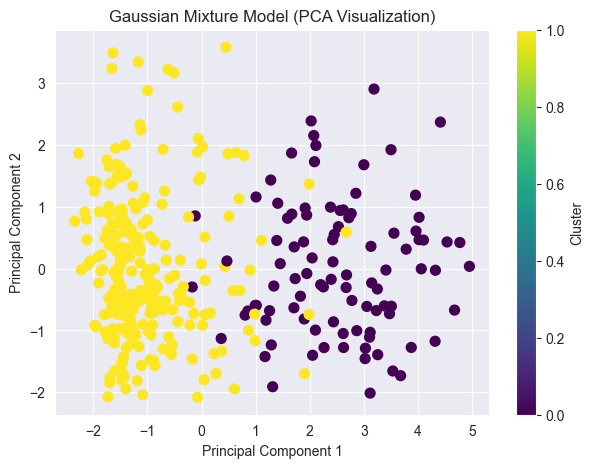

In [24]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap="viridis", s=50)

plt.title("Gaussian Mixture Model (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()


- The GMM model formed two reasonably separated clusters.
- The clustering pattern is similar to K-Means and Hierarchical Clustering.

### 5. Mean Shift

- #### Hyperparameter Tuning
  The Mean Shift algorithm is tuned by testing different bandwidth values. The best bandwidth is selected based on the Silhouette Score.

In [25]:
bandwidth_values = [0.8, 1.0, 1.2, 1.5, 2.0]

results = []
for bandwidth in bandwidth_values:
    meanshift = MeanShift(bandwidth=bandwidth)
    labels = meanshift.fit_predict(X_standard)

    # Ignore cases where only one cluster is formed
    if len(set(labels)) > 1:
        results.append({
            "Bandwidth": bandwidth,
            "Clusters": len(set(labels)),
            "Silhouette Score": silhouette_score(X_standard, labels)
        })
meanshift_results = pd.DataFrame(results)
display(meanshift_results)


,Bandwidth,Clusters,Silhouette Score
0,0.8,202,0.102955
1,1.0,161,0.121583
2,1.2,109,0.108523
3,1.5,59,0.145014
4,2.0,16,0.122283


- The highest **Silhouette Score (0.1450)** was obtained with **bandwidth = 1.5**.
- Therefore, **bandwidth = 1.5** was selected for the final Mean Shift model.

- #### Applying Mean Shift

In [26]:
meanshift = MeanShift(bandwidth=1.5)
meanshift_labels = meanshift.fit_predict(X_standard)

# Display cluster distribution
print("Cluster Distribution:")
print(pd.Series(meanshift_labels).value_counts().sort_index())


Cluster Distribution:
0     111
1      31
2      20
3      14
4      13
5       7
6       8
7       8
8       8
9       4
10      5
11      4
12      4
13      4
14      3
15      3
16      4
17      2
18      1
19      1
20      1
21      1
22      2
23      1
24      2
25      1
26      2
27      1
28      1
29      1
30      1
31      1
32      1
33      1
34      1
35      3
36      2
37      4
38      3
39      1
40      1
41      4
42      4
43      1
44      2
45      1
46      4
47      2
48      8
49      6
50      1
51      1
52      2
53      2
54      2
55      1
56      1
57      2
58      1
Name: count, dtype: int64


- #### Evaluating Mean Shift

In [27]:
silhouette = silhouette_score(X_standard, meanshift_labels)
davies = davies_bouldin_score(X_standard, meanshift_labels)
calinski = calinski_harabasz_score(X_standard, meanshift_labels)
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")


Silhouette Score: 0.1450
Davies-Bouldin Index: 0.8903
Calinski-Harabasz Index: 23.0533


- #### Cluster Visualization using PCA

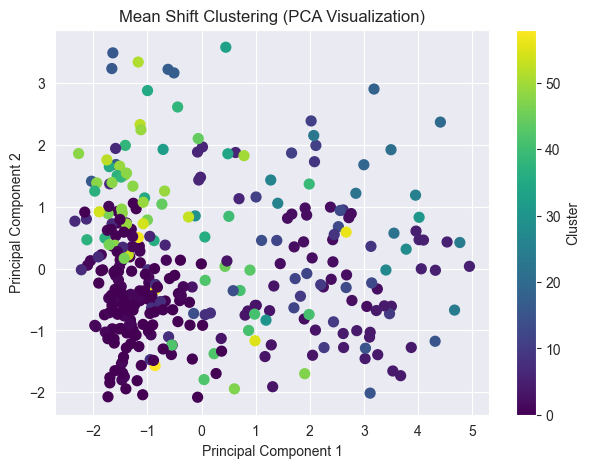

In [28]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=meanshift_labels, cmap="viridis", s=50)

plt.title("Mean Shift Clustering (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()


- Mean Shift produced many small clusters with one dominant cluster.
- This indicates over-segmentation, making Mean Shift less suitable for this dataset.

### Comparison of Clustering Algorithms

- Although DBSCAN achieved the highest Silhouette Score, this result is misleading because it classified **214 out of 332 samples as noise** and calculated the evaluation metrics only on the remaining clustered samples.
- Since K-Means, Hierarchical Clustering, Gaussian Mixture Model, and Mean Shift were evaluated using the entire dataset, DBSCAN is interpreted separately and is not directly compared with the other algorithms.

In [29]:
# Comparison of clustering algorithms (excluding DBSCAN)
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "Gaussian Mixture",
        "Mean Shift"
    ],
    "Silhouette Score": [
        0.3561,
        0.3521,
        0.3472,
        0.1450
    ],
    "Davies-Bouldin Index": [
        1.2004,
        1.2075,
        1.2224,
        0.8903
    ],
    "Calinski-Harabasz Index": [
        176.6546,
        169.8709,
        163.7448,
        23.0533
    ]
})
comparison


,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.3561,1.2004,176.6546
1,Hierarchical,0.3521,1.2075,169.8709
2,Gaussian Mixture,0.3472,1.2224,163.7448
3,Mean Shift,0.1450,0.8903,23.0533


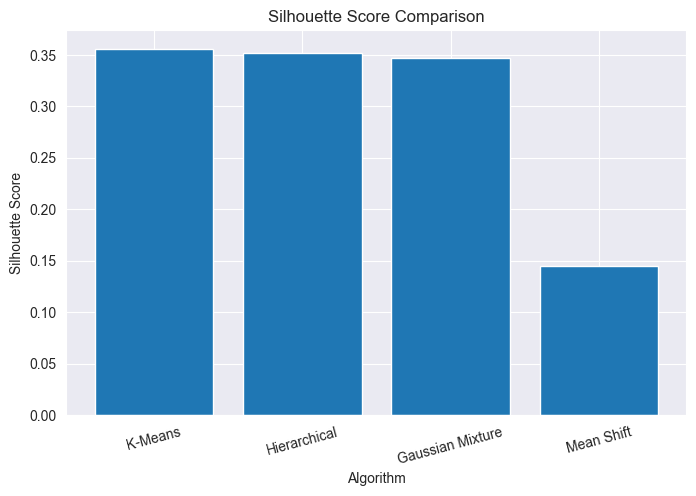

In [30]:
plt.figure(figsize=(8,5))
plt.bar(comparison["Algorithm"], comparison["Silhouette Score"])
plt.title("Silhouette Score Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=15)

plt.show()

**Comparison**

- **K-Means** achieved the best overall performance, with the highest Calinski-Harabasz Index and good cluster separation while clustering the entire dataset.
- **Hierarchical Clustering** produced results very similar to K-Means but with slightly lower evaluation metrics.
- **Gaussian Mixture Model (GMM)** also generated well-separated clusters but performed slightly below K-Means and Hierarchical Clustering.
- **Mean Shift** created many small clusters, indicating over-segmentation and the weakest overall performance.

**Conclusion**

Based on the evaluation metrics and clustering results, **K-Means** was selected as the best clustering algorithm for the Wholesale Customers dataset because it produced well-separated clusters while effectively utilizing all available samples.

## High-Dimensional Dataset

#### Loading and Inspecting the Dataset


In [31]:
mobile_df = pd.read_csv("Datasets/mobile_price_data.csv")
mobile_df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [32]:
# Dataset inspection
print("Dataset Shape:", mobile_df.shape)

print("\nDataset Information:")
mobile_df.info()

print("\nMissing Values:")
print(mobile_df.isnull().sum())

print("\nDuplicate Rows:", mobile_df.duplicated().sum())

print("\nStatistical Summary:")
display(mobile_df.describe())

Dataset Shape: (2000, 21)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


**Observation**

- The dataset contains **2000 samples** and **21 features**.
- No missing values or duplicate records were found.
- The dataset is clean and ready for preprocessing.

#### Data Preprocessing

In [33]:
# Separate features and target
X = mobile_df.drop("price_range", axis=1)
y = mobile_df["price_range"]

# Detect outliers using IQR
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)

# Remove outliers
X_clean = X[outlier_mask]
y_clean = y[outlier_mask]
print("Original Shape :", X.shape)
print("After Removing Outliers :", X_clean.shape)

# Feature Scaling
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
X_standard = standard_scaler.fit_transform(X_clean)
X_minmax = minmax_scaler.fit_transform(X_clean)
X_robust = robust_scaler.fit_transform(X_clean)
print("\nStandardScaler Shape:", X_standard.shape)
print("MinMaxScaler Shape:", X_minmax.shape)
print("RobustScaler Shape:", X_robust.shape)


Original Shape : (2000, 20)
After Removing Outliers : (1506, 20)

StandardScaler Shape: (1506, 20)
MinMaxScaler Shape: (1506, 20)
RobustScaler Shape: (1506, 20)


### Dimensionality Reduction Techniques

Dimensionality reduction techniques are applied to transform the high-dimensional dataset into a lower-dimensional representation while preserving important information. The performance of different techniques is evaluated and compared using appropriate visualizations and analysis.

### 1. Principal Component Analysis (PCA)

- #### Hyperparameter Tuning

In [34]:
results = []
for n in range(2, 11):
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_standard)

    results.append({
        "Components": n,
        "Explained Variance Ratio": pca.explained_variance_ratio_.sum()
    })
pca_results = pd.DataFrame(results)
pca_results


,Components,Explained Variance Ratio
0,2,0.171871
1,3,0.248388
2,4,0.309204
3,5,0.367718
4,6,0.424180
5,7,0.479711
6,8,0.532808
7,9,0.585242
8,10,0.637172


- The explained variance increased as the number of components increased.
- 10 components achieved the highest explained variance (**63.72%**) and were selected for PCA.

- #### Applying PCA

In [35]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_standard)
print("Original Shape:", X_standard.shape)
print("Reduced Shape:", X_pca.shape)
print("\nExplained Variance Ratio:", pca.explained_variance_ratio_.sum())


Original Shape: (1506, 20)
Reduced Shape: (1506, 10)

Explained Variance Ratio: 0.6371717595721366


- PCA reduced the dataset from 20 to 10 features.
- The selected components retained **63.72%** of the total variance.

- #### PCA Visualization

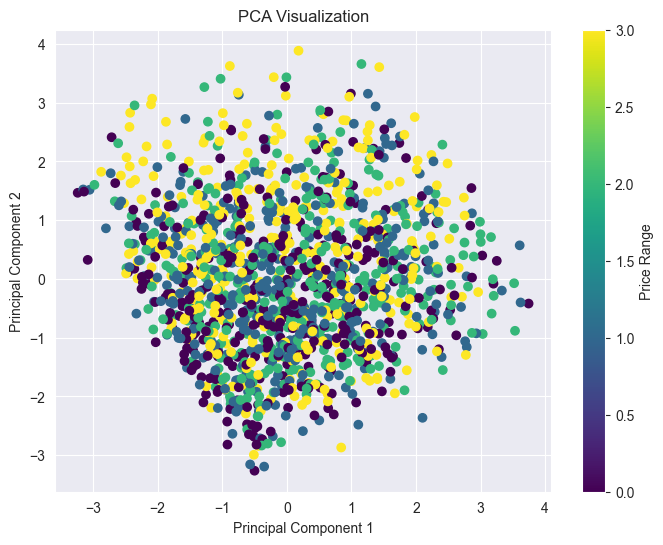

In [36]:
# Visualize the first two principal components
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_standard)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca_vis[:, 0],
    X_pca_vis[:, 1],
    c=y_clean,
    cmap="viridis"
)
plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Price Range")
plt.show()


- The first two principal components captured the major variation in the data.
- The different price ranges show considerable overlap, indicating that the data is not clearly separable in two dimensions.


### 2. Kernel Principal Component Analysis (Kernel PCA)

- #### Applying Kernal PCA

In [38]:
# Apply Kernel PCA
kpca = KernelPCA(
    n_components=10,
    kernel="rbf",
    gamma=0.05,
    random_state=42
)
X_kpca = kpca.fit_transform(X_standard)

print("Original Shape:", X_standard.shape)
print("Reduced Shape:", X_kpca.shape)

Original Shape: (1506, 20)
Reduced Shape: (1506, 10)


**Observation**

- Kernel PCA reduced the dataset from **20** to **10** features.
- It preserves non-linear relationships by transforming the data into a higher-dimensional feature space before reducing its dimensions.

- #### Visualization

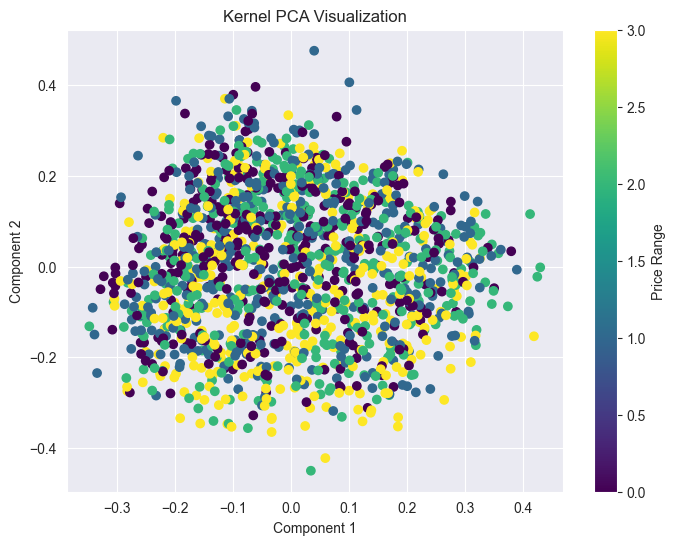

In [39]:
kpca_vis = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.05,
    random_state=42
)
X_kpca_vis = kpca_vis.fit_transform(X_standard)

plt.figure(figsize=(8,6))
plt.scatter(
    X_kpca_vis[:, 0],
    X_kpca_vis[:, 1],
    c=y_clean,
    cmap="viridis"
)
plt.title("Kernel PCA Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Price Range")
plt.show()


- Kernel PCA produced a more compact distribution of the data compared to PCA.
- The different price ranges still overlap considerably, indicating limited class separation in two dimensions.

### 4. t-Distributed Stochastic Neighbor Embedding (t-SNE)

- #### Applying t-SNE

In [41]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_standard)

print("Original Shape:", X_standard.shape)
print("Reduced Shape:", X_tsne.shape)


Original Shape: (1506, 20)
Reduced Shape: (1506, 2)


**Observation**

- t-SNE reduced the dataset from **20** to **2** dimensions.
- It preserves the local structure of the high-dimensional data in a two-dimensional space.

- #### Visualization

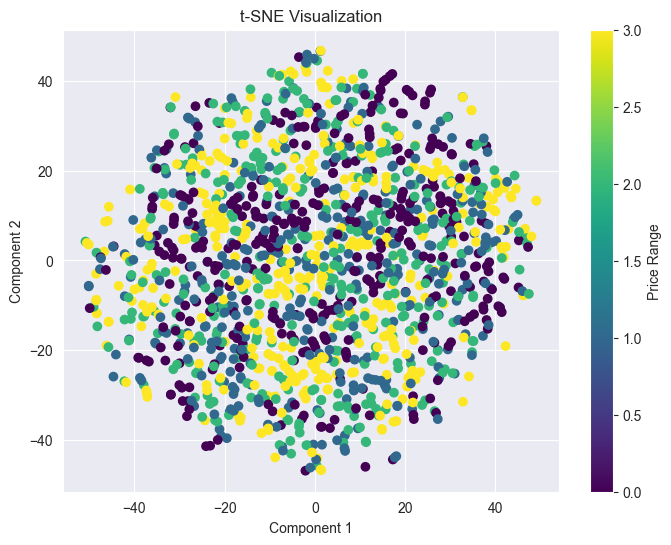

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_clean,
    cmap="viridis"
)
plt.title("t-SNE Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Price Range")

plt.show()


- t-SNE preserved the local structure of the data but the different price ranges still show noticeable overlap.
- No clear separation between the classes is observed in the two-dimensional visualization.